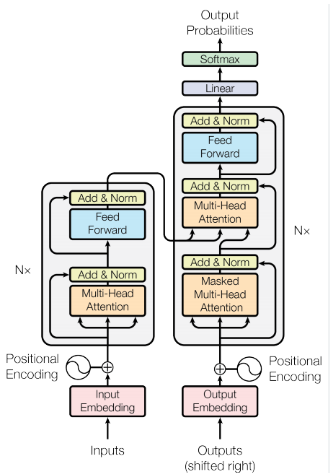

**WorkFlow ->**
1. Input Embedding
2. Positional Encoding
3. MultiHead Attention
4. Add and Normalization
5. FeedForward Network
6. Residual Network
7. Encoder
8. Decoder and Projection Layer
9. Building a transformer
10. Test our Transformer
11. Tokenizer
12. Loading dataset
13. Validation Loop
14. Training Loop
15. Conclusion

Have a look at > [https://jalammar.github.io/illustrated-transformer/](http://)

# Importing Library

In [393]:
import torch  
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter

# Math
import math

# Hugging Face Library
from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.trainers import WordLevelTrainer
from tokenizers.pre_tokenizers import Whitespace

# Pathlib
from pathlib import Path

# Typing
from typing import Any

# Lib for displaing process while in loop
from tqdm import tqdm

# wwarnings
import warnings

# **1.Input Embedding** 
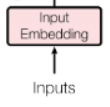

In [394]:
# example :on paper d_model = 512

In [395]:
class InputEmbeddings(nn.Module):
    def __init__(self, d_model:int , vocab_size:int):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size,d_model)

    def forward(self,x):
        return self.embedding(x) * math.sqrt(self.d_model)
        
     

# 2.Positional Encoding
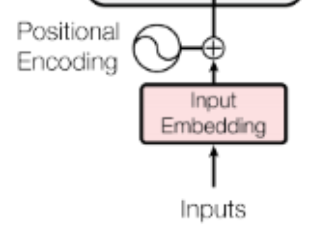


We will be just using a simple math formula for it .
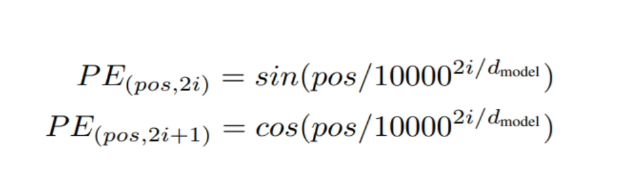


here d_model = 512


* sin() for even
* cos() for odd

assume "**animal**" word have embedding [0.2,0.3...] so apply sin on 0.2 and cos on 0.3 and continue for all 512 vector.

little change in formula convert to this :
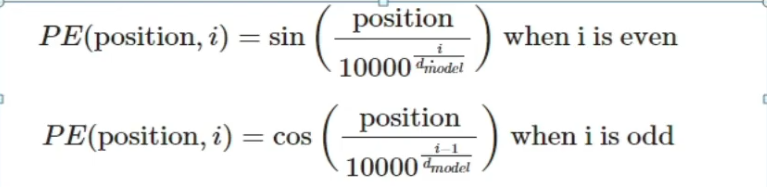

In [396]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model:int, seq_len:int ,dropout:float):
        super().__init__()
        self.d_model = d_model
        self.seq_len = seq_len
        self.dropout=nn.Dropout(dropout)

        pe = torch.zeros(seq_len,d_model)
        position = torch.arange(0,seq_len,dtype=torch.float).unsqueeze(1) #[seq_len,1] unsequze add one dimension
        # div_term=torch.exp(torch.arrange(0,d_model,2).float() ) this was the code acc. to paper but that log beacuse for better acc to researcher down there
        div_term=torch.exp(torch.arange(0,d_model,2).float() * (-math.log(10000.0) / d_model))
        pe[:,0::2] = torch.sin(position * div_term)
        pe[:,1::2] = torch.cos(position * div_term)
        pe=pe.unsqueeze(0)
        self.register_buffer('pe',pe) #we donot need to train them for that we add this line

    def forward(self, x):
        # I fixed the slicing bug here! It needs to be :x.shape[1]
        x = x + (self.pe[:, :x.shape[1], :]).requires_grad_(False)
        return self.dropout(x)
                

#  3. MultiHead Self Attention

**Formula:**

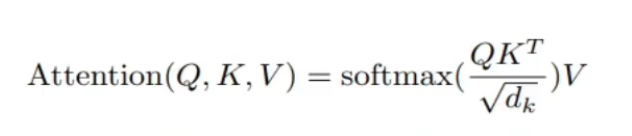

* First **q** got multiplied by transpose of **k** using matmul 
* second divide by root dk so that we can decrese varience becuse as we increase dimenion the varience increase that many times so did this thing
* apply softmax formula(exp(x)/sigma(exp()x) over it
* matmul with v 

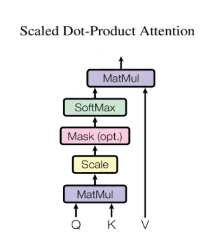

* The input will consist of queries and keys of dimention dk
* q:d_k
* k:d_k

* values of dimention dv
* v:d_v

query: what i am looking for

key: what i can offered

value : what i actually offered


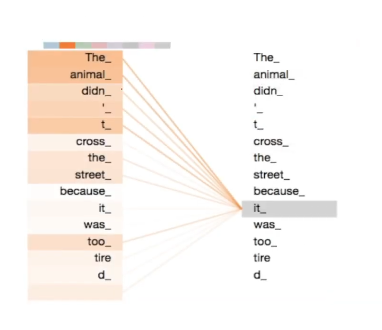

from paper
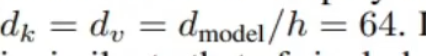

so we will simply make three 

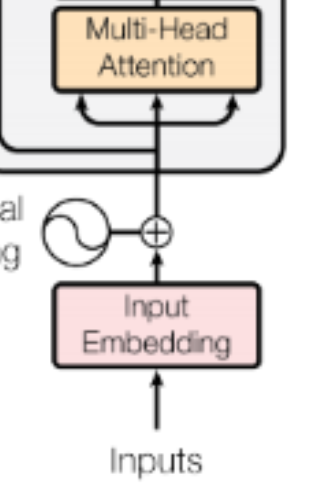

for masking we only add M:
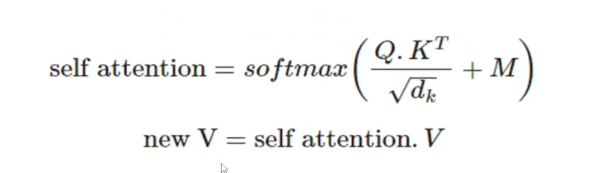

mask will look like this here replace 1 with 0 and 0 with -infinity
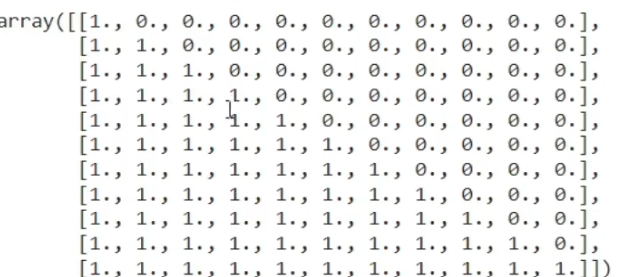

softmax will convert the -inf to 0 .

**now that was attention lets have a look at multiHead attention**

multihead attention is simply getting prespective of lot of people it means now "it" word in above image judge the sentencce each word from different angles and give score on each angle

In [397]:
class MultiHeadAttentionBlock(nn.Module):

    def __init__(self , d_model:int , h:int , dropout:float ) -> None :
        super().__init__()
        self.d_model = d_model
        self.h = h
        assert d_model % h == 0, 'D_model is not visible' #assert this just looks at the condtion and throws error
        self.d_k = d_model // h
        self.w_q = nn.Linear(d_model , d_model)
        self.w_k = nn.Linear(d_model , d_model)
        self.w_v = nn.Linear(d_model , d_model)
        self.w_o = nn.Linear(d_model , d_model)
        self.dropout = nn.Dropout(dropout)

    # talking about static function in class , just one funcction for all instannce of class
    @staticmethod
    def attention(query, key, value, mask, dropout:nn.Dropout):
        # we donot try to put hardcode numbers
        d_k = query.shape[-1]
        #@ same as matmul like matrix multiplication
        attention_score = (query @ key.transpose(-2,-1)) /math.sqrt(d_k)
        if mask is not None:
            attention_score.masked_fill_(mask==0,-1e9)
        attention_score=attention_score.softmax(dim=-1)
        if dropout is not None:
            attention_score = dropout(attention_score)
        return (attention_score @ value) , attention_score

    def forward(self,q,k,v,mask):
        query = self.w_q(q) #(1,11,512)
        key = self.w_k(k)
        value = self.w_v(v)
        # i could have used reshape here instead of view but the reason for using view is that it changes in the object itself rather than creating a copy 
        query = query.view(query.shape[0], query.shape[1], self.h, self.d_k).transpose(1,2) #(1,8,11,64)
        key = key.view(key.shape[0],key.shape[1],self.h,self.d_k).transpose(1,2) 
        value = value.view(value.shape[0],value.shape[1],self.h,self.d_k).transpose(1,2) 
        x,self.attention_scores = MultiHeadAttentionBlock.attention(query,key,value,mask,self.dropout)
        # (1,8,11,64)
        # x = x.transpose(1,2)    # (1,11,8,64)
        # combining the heads
        # x = x.view(x.shape[0],-1,self.h * self.d_k)
        # sometime i gorget this -1 so it simply is there to main the multiplication number
        #combining it with contingeour to ensure that all these allocation happen in one bloack of memory
        x = x.transpose(1,2).contiguous().view(x.shape[0],-1,self.h * self.d_k)
        return self.w_o(x)
        
        

Last step logic combinig or simply intermixing finding of all heads:
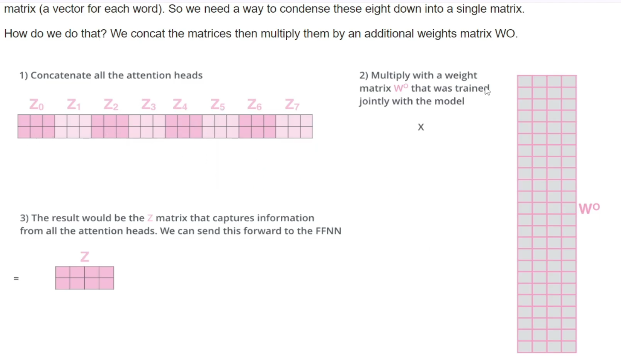

# 4.Layer Normalization

Hope you know mean,varience nd standard daviation, just google it for formuala

In normaization we just mean center our input by subtracting mean and divide by standard daviation for standarizing the data means the spread of the data. 

* beta is there to shift the data

* gamma is there to spread the data

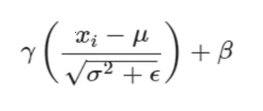

In [398]:
class LayerNormalization(nn.Module):
    def __init__(self,eps:float=10**-6 ) -> None :
        super().__init__()
        self.eps = eps
        self.alpha = nn.Parameter(torch.ones(1))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self , x ):
        mean = x.mean(dim=-1 , keepdim =True) #we want mean of last dimension 
        std = x.std(dim=-1,keepdim = True)
        return self.alpha * (x-mean)/(std + self.eps) + self.bias        
        

# 5. Feed Forward Network

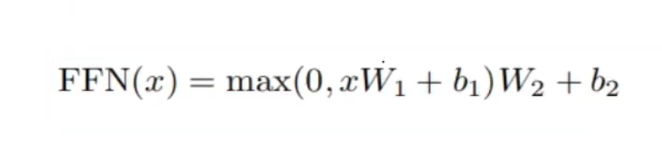

 This consist of two linear transforamtion with a RELU activation in b/w.

from paper:
 * input=512 
 * output=512
 * inner layer = 2048

In [399]:
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model:int , d_ff:int, dropout:float) -> None:
        super().__init__()
        self.linear_1 = nn.Linear(d_model , d_ff)
        self.dropout=nn.Dropout(dropout)
        self.linear_2 = nn.Linear(d_ff,d_model)

    def forward(self ,x):
        # b = self.linear_1(x)
        # s = torch.relu(b)
        # e = self.dropout(s)
        # z = self.linear_2(e)
        # Professional way same above thing
        return self.linear_2(self.dropout(torch.relu(self.linear_1(x))))
        
        

# 6. Residual Connection

you can see the residual connections here :
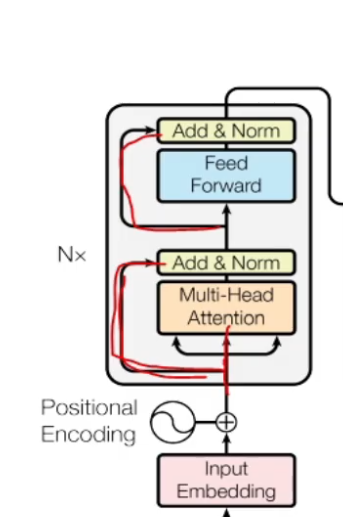

we will write it once and use it for all the transformer

In [400]:
class ResidualConnection(nn.Module):
    def __init__(self , dropout:float ) ->None:
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.norm = LayerNormalization()

    def forward(self,x,sublayer):
        # return x + self.norm(sublayer(x)) this is done what it simply mean is first send to sublayer it can be Multihead attention or it can be FeedForward layer normalize it then add
        # but for prevent over fitting we does it 
        # return x + self.dropout(self.norm(sublayer(x))) this is correct but acc to mit engneer for better
        return x + self.dropout(sublayer(self.norm(x)))

It is done to prevent vanishing gradient problem

# 7.Encoder

* **stack of N=6 Identical Layers**
* **Each layer has two sub-Layers (MultiHead , FeedForward)**

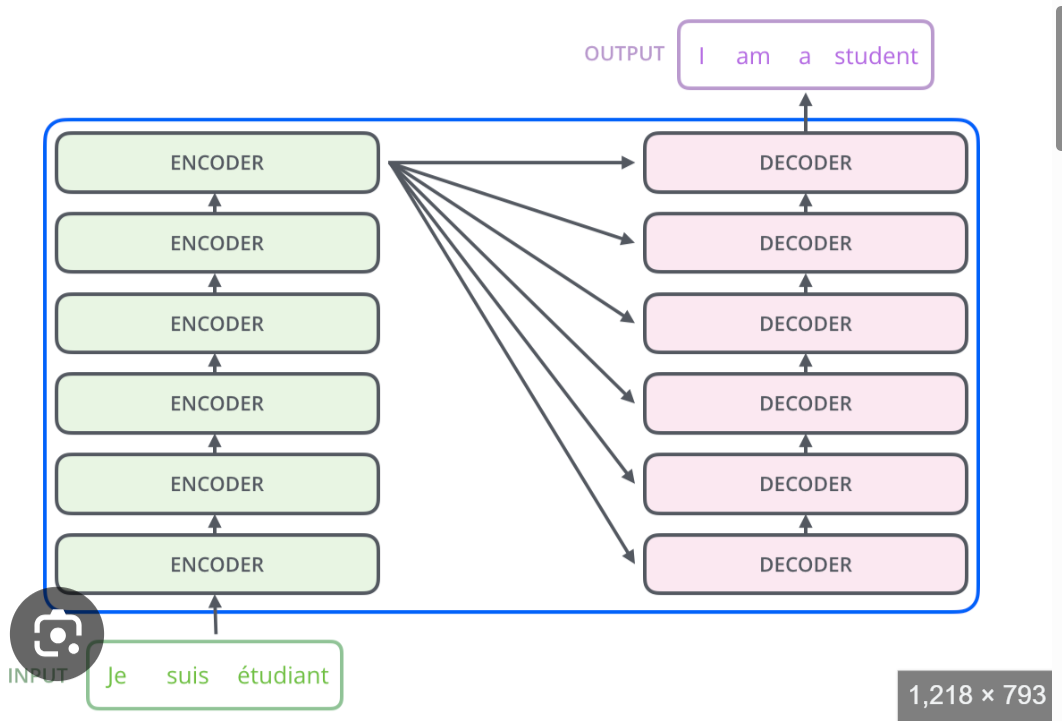

we will take the key and value from the encoder

First we will mke a single encode then for 6
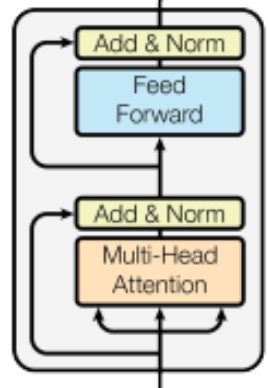

here is only 1 block:

In [401]:
 class EncoderBlock(nn.Module):
     def __init__(self, self_attention_block:  MultiHeadAttentionBlock , feed_forward_block:FeedForwardBlock , dropout:float )->None:
         super().__init__()
         self.self_attention_block = self_attention_block #here i got the instance of multiheadattention class
         self.feed_forward_block = feed_forward_block
         self.residual_connections = nn.ModuleList([ResidualConnection(dropout) for _ in range(2) ]) #making a instance of residual connection class but each layer of enccoder consit of two of these one for multihead other for feedforward
         # the nn.moduleList is used to store sub class in there

     def forward(self , x , src_mask):
         # the reason for the src msk is that ech sentence which is going in model in of different length so we add something in smll sentence to make them of corect length its <pad> chatgpt it  
         x = self.residual_connections[0](x, lambda x: self.self_attention_block(x,x,x,src_mask) ) # that k , q , v and mask is getting sended
         # 0 beacuse there are two residual connections
         x = self.residual_connections[1](x , self.feed_forward_block)
         return x     
          

now attaching all of them just one mpre thing after passing it with 6 encoder we will normalize it 

In [402]:
class Encoder(nn.Module):
    # just assume that nnModuleList for now contain encoder of quantity 6
    def __init__(self, layers: nn.ModuleList )->None :
        super().__init__()
        self.layers = layers
        self.norm = LayerNormalization()

    def forward(self,x,mask):
        for layer in self.layers:
            x = layer(x,mask)
        return self.norm(x)
        

# 8. Decoder

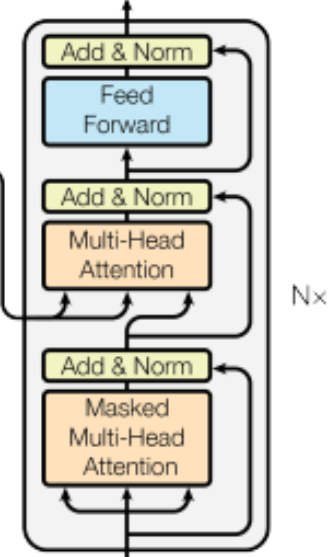

In [403]:
class DecoderBlock(nn.Module):
    def __init__(self,self_attention_block: MultiHeadAttentionBlock ,cross_attention_block: MultiHeadAttentionBlock , feed_forward_block:FeedForwardBlock , dropout:float )->None:
        super().__init__()
        self.self_attention_block = self_attention_block #here i got the instance of multiheadattention class
        self.cross_attention_block = cross_attention_block
        self.feed_forward_block = feed_forward_block
        self.residual_connections = nn.ModuleList([ResidualConnection(dropout) for _ in range(3) ])

    def forward(self,x,encoder_output, src_mask , target_mask):
        x = self.residual_connections[0](x, lambda x:self.self_attention_block(x,x,x,target_mask))
        x = self.residual_connections[1](x, lambda x:self.cross_attention_block(x, encoder_output,encoder_output ,src_mask))
        x = self.residual_connections[2](x , self.feed_forward_block)
        return x


In [404]:
class Decoder(nn.Module):
    def __init__(self, layers: nn.ModuleList )->None :
        super().__init__()
        self.layers = layers
        self.norm = LayerNormalization()

    def forward(self,x,encoder_output,src_mask, target_mask):
        for layer in self.layers:
            x = layer(x,encoder_output, src_mask , target_mask)
        return self.norm(x)
    

# Linear Layer

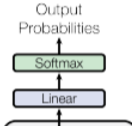

In [405]:
class ProjectionLayer(nn.Module):
    def __init__(self, d_model:int , vocab_size:int) -> None:
        super().__init__()
        self.projection = nn.Linear(d_model , vocab_size)

    def forward(self ,x):
        return torch.log_softmax(self.projection(x), dim=-1)

# 9. Building the transformer

In [406]:
class Transformer(nn.Module):
    def __init__(self , encoder : Encoder , decoder : Decoder , src_embed: InputEmbeddings , target_embed:InputEmbeddings , src_pos: PositionalEncoding, target_pos:PositionalEncoding , projection_layer:ProjectionLayer)->None:
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.target_embed = target_embed
        self.src_pos = src_pos
        self.target_pos = target_pos
        self.projection_layer = projection_layer

    def encode(self,src,src_mask):
        src = self.src_embed(src)
        src = self.src_pos(src)
        return self.encoder(src , src_mask)

    def decode(self , encoder_output, src_mask , target, target_mask):
        target = self.target_embed(target)
        target = self.target_pos(target)
        return self.decoder(target ,encoder_output , src_mask, target_mask)

    def project(self,x):
        return self.projection_layer(x)

All work is done hurray 

Just Kidding , well kidding also means the child of a goat

#  10 .Build Transformer

In [407]:
# Notice now we are making function
# we earlier disscussed difference in vacb and seq len
def build_transformer(src_vocab_size:int , target_vocab_size:int , src_seq_len:int , target_seq_len:int , d_model:int=512 , N:int=6 , h:int=8 , dropout:float=0.1,d_ff:int=2048) -> Transformer:
    src_embed = InputEmbeddings(d_model,src_vocab_size)
    target_embed = InputEmbeddings(d_model , target_vocab_size)
    src_pos = PositionalEncoding(d_model, src_seq_len, dropout)
    target_pos = PositionalEncoding(d_model , target_seq_len, dropout)
    
    encoder_blocks=[]
    for _ in range(N):
        encoder_self_attention_block=MultiHeadAttentionBlock(d_model , h , dropout)
        feed_forward_block=FeedForwardBlock(d_model, d_ff,dropout)
        encoder_block = EncoderBlock(encoder_self_attention_block , feed_forward_block ,dropout)
        encoder_blocks.append(encoder_block)

    decoder_blocks=[]
    for _ in range(N):
        decoder_self_attention_block=MultiHeadAttentionBlock(d_model , h , dropout)
        decoder_cross_attention_block=MultiHeadAttentionBlock(d_model , h , dropout)
        feed_forward_block=FeedForwardBlock(d_model, d_ff,dropout)
        decoder_block = DecoderBlock(decoder_self_attention_block ,decoder_cross_attention_block, feed_forward_block ,dropout)
        decoder_blocks.append(decoder_block)

    encoder = Encoder(nn.ModuleList(encoder_blocks)) #it got converted to module list we send it to encoder
    decoder = Decoder(nn.ModuleList(decoder_blocks))
    projection_layer=ProjectionLayer(d_model, target_vocab_size)
    transformer = Transformer(encoder , decoder , src_embed, target_embed ,src_pos, target_pos, projection_layer)
    for p in transformer.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
            # interesting info there is a "_" after uniform here it means change in place rather than creating a copy
            # the parameters who have dimention greater than one
            # the variance of the outputs of a layer needs to be exactly equal to the variance of its inputs. Simply put: If 512 numbers flow into a Linear layer, the 512 numbers that flow out shouldn't be drastically larger or drastically smaller.
    return transformer
    
        
        
     

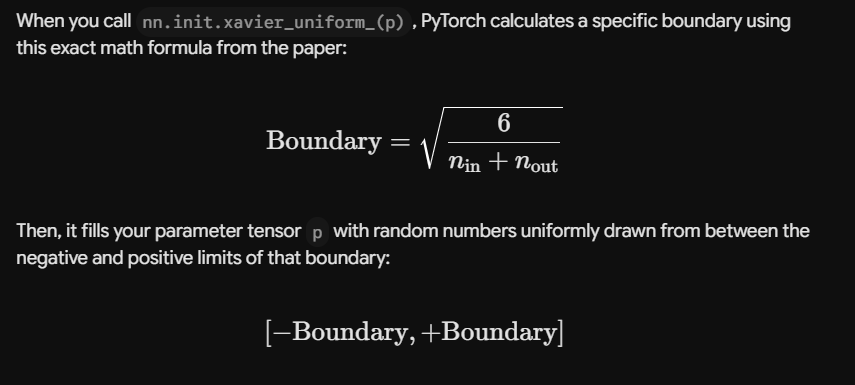

# 11.Tokenization

In [408]:
def build_tokenizer(config , ds, lang):

    tokenizer_path = Path(config['tokenizer_file'].format(lang)) #creates a file path (e.g., "data/tokenizer_en.json") where we will save our finished dictionary.

    if not Path.exists(tokenizer_path):
        tokenizer = Tokenizer(WordLevel(unk_token = '[UNK]')) #it simply We are telling Hugging Face to create a WordLevel tokenizer.
        # unk_token = '[UNK]': This stands for Unknown. If you train your model, and tomorrow a user inputs a word the model has never seen before , the tokenizer won't crash.
        tokenizer.pre_tokenizer = Whitespace() #"My name is Himanshu" becomes ["My", "name", "is", "Himanshu"].
        trainer = WordLevelTrainer(special_tokens = [
            "[UNK]" , "[PAD]" , "[SOS]" , "[EOS]"
        ], min_frequency = 2)
        
        # min_frequency = 2: This is a brilliant data-cleaning trick.
        # [UNK]: Unknown word.
        # [PAD]: The padding token! (We just talked about this. This is the fake word we use to make short sentences match the length of long sentences in a batch).
        # [SOS]: Start Of Sentence.
        # [EOS]: End Of Sentence.
        
        tokenizer.train_from_iterator(get_all_sentences(ds, lang) , trainer = trainer)
        tokenizer.save(str(tokenizer_path))
    else:
        tokenizer = Tokenizer.from_file(str(tokenizer_path))
    return tokenizer
                          

A Tokenizer is simply a giant dictionary that maps words to integers.

"hello" -> 45

"world" -> 102

This function builds that exact dictionary by reading your entire dataset, finding all the unique words, assigning them IDs, and saving the dictionary to a file so you don't have to rebuild it every time you run your code.

# 12.Loading DataSet

In [409]:
def get_all_sentences(ds, lang):
    for pair in ds:
        yield pair['translation'][lang]
        

This is how your dataset will look ->

* ds = [    {"translation": {"en": "My name is Himanshu", "fr": "Je m'appelle Himanshu"}},       {"translation": {"en": "PyTorch is cool", "fr": "PyTorch est cool"}},    # ... 10 million more rows ...]

By swapping return for yield, you completely change the nature of the function. You turn it into a Generator.

A Generator does not run the whole loop at once. It runs exactly one cycle of the loop, hands the data over, and then hits the pause button on the function.


In [410]:
def get_ds(config):

    ds_raw = load_dataset('opus_books', f'{config["lang_src"]}-{config["lang_tgt"]}', split = 'train')

    tokenizer_src = build_tokenizer(config, ds_raw, config['lang_src'])
    tokenizer_tgt = build_tokenizer(config, ds_raw, config['lang_tgt'])

    train_ds_size = int(0.9 * len(ds_raw))
    val_ds_size = len(ds_raw) - train_ds_size
    train_ds_raw, val_ds_raw = random_split(ds_raw,[train_ds_size,val_ds_size])

    train_ds = BilingualDataset(train_ds_raw, tokenizer_src , tokenizer_tgt, config['lang_src'], config['lang_tgt'], config['seq_len'])
    val_ds = BilingualDataset(val_ds_raw, tokenizer_src , tokenizer_tgt, config['lang_src'], config['lang_tgt'], config['seq_len'])

    max_len_src = 0
    max_len_tgt = 0
    for pair in ds_raw:
        src_ids = tokenizer_src.encode(pair['translation'][config['lang_src']]).ids
        # tokenizer_src.encode(pair['translation'][config['lang_src']]).id
        # tokenizer_src.encode(pair['translation']['en']).ids
        # tokenizer_src.encode("My name is Himanshu").ids
        # [Encoding_Object].ids
        # [102, 450, 12, 8943]
        tgt_ids = tokenizer_tgt.encode(pair['translation'][config['lang_tgt']]).ids
        max_len_src = max(max_len_src, len(src_ids))
        max_len_tgt = max(max_len_tgt, len(tgt_ids)) 

    print(f'Max length of the souce sentence: {max_len_src}')
    print(f'Max length of the target sentence: {max_len_tgt}')

    train_dataloader = DataLoader(train_ds, batch_size = config['batch_size'], shuffle = True)
    val_dataloader = DataLoader(val_ds, batch_size = 1 , shuffle = True)

    return train_dataloader, val_dataloader, tokenizer_src, tokenizer_tgt
    

# Casual Mask

In [411]:
def causal_mask(size):
    mask = torch.triu(torch.ones(1,size,size), diagonal = 1).type(torch.int)
    return mask == 0

# got this msk :
# [True,  False, False, False] # Word 1 can only see Word 1
# [True,  True,  False, False] # Word 2 can see Word 1 and 2
# [True,  True,  True,  False] # Word 3 can see Word 1, 2, and 3
# [True,  True,  True,  True ] # Word 4 can see everything

In [412]:
#BilingualDataset job is to take raw text, turn it into numbers, format it perfectly into uniform blocks, and inject it into the model one sentence at a time.

class BilingualDataset(Dataset):

    # This takes in the dataset contaning sentence pairs, the tokenizers for target and source languages, and the strings of source and target languages
    # 'seq_len' defines the sequence length for both languages
    def __init__(self, ds, tokenizer_src, tokenizer_tgt, src_lang, tgt_lang, seq_len) -> None:
        super().__init__()

        self.seq_len = seq_len
        self.ds = ds
        self.tokenizer_src = tokenizer_src
        self.tokenizer_tgt = tokenizer_tgt
        self.src_lang = src_lang
        self.tgt_lang = tgt_lang

        # Defining special tokens by using the target language tokenizer
        self.sos_token = torch.tensor([tokenizer_tgt.token_to_id("[SOS]")], dtype=torch.int64)
        self.eos_token = torch.tensor([tokenizer_tgt.token_to_id("[EOS]")], dtype=torch.int64)
        self.pad_token = torch.tensor([tokenizer_tgt.token_to_id("[PAD]")], dtype=torch.int64)


    # Total number of instances in the dataset (some pairs are larger than others)
    def __len__(self):
        return len(self.ds)

    # Using the index to retrive source and target texts
    def __getitem__(self, index: Any) -> Any:
        src_target_pair = self.ds[index]
        src_text = src_target_pair['translation'][self.src_lang]
        tgt_text = src_target_pair['translation'][self.tgt_lang]

        # Tokenizing source and target texts
        enc_input_tokens = self.tokenizer_src.encode(src_text).ids
        dec_input_tokens = self.tokenizer_tgt.encode(tgt_text).ids

        # Computing how many padding tokens need to be added to the tokenized texts
        # Source tokens
        enc_num_padding_tokens = self.seq_len - len(enc_input_tokens) - 2 # Subtracting the two '[EOS]' and '[SOS]' special tokens
        # Target tokens
        dec_num_padding_tokens = self.seq_len - len(dec_input_tokens) - 1 # Subtracting the '[SOS]' special token

        # If the texts exceed the 'seq_len' allowed, it will raise an error. This means that one of the sentences in the pair is too long to be processed
        # given the current sequence length limit (this will be defined in the config dictionary below)
        if enc_num_padding_tokens < 0 or dec_num_padding_tokens < 0:
            raise ValueError('Sentence is too long')

        # Building the encoder input tensor by combining several elements
        encoder_input = torch.cat(
            [
            self.sos_token, # inserting the '[SOS]' token
            torch.tensor(enc_input_tokens, dtype = torch.int64), # Inserting the tokenized source text
            self.eos_token, # Inserting the '[EOS]' token
            torch.tensor([self.pad_token] * enc_num_padding_tokens, dtype = torch.int64) # Addind padding tokens
            ]
        )

        # Building the decoder input tensor by combining several elements
        decoder_input = torch.cat(
            [
                self.sos_token, # inserting the '[SOS]' token
                torch.tensor(dec_input_tokens, dtype = torch.int64), # Inserting the tokenized target text
                torch.tensor([self.pad_token] * dec_num_padding_tokens, dtype = torch.int64) # Addind padding tokens
            ]

        )

        # Creating a label tensor, the expected output for training the model
        label = torch.cat(
            [
                torch.tensor(dec_input_tokens, dtype = torch.int64), # Inserting the tokenized target text
                self.eos_token, # Inserting the '[EOS]' token
                torch.tensor([self.pad_token] * dec_num_padding_tokens, dtype = torch.int64) # Adding padding tokens

            ]
        )

        # Ensuring that the length of each tensor above is equal to the defined 'seq_len'
        assert encoder_input.size(0) == self.seq_len
        assert decoder_input.size(0) == self.seq_len
        assert label.size(0) == self.seq_len

        return {
            'encoder_input': encoder_input,
            'decoder_input': decoder_input,
            'encoder_mask': (encoder_input != self.pad_token).unsqueeze(0).unsqueeze(0).int(),
            'decoder_mask': (decoder_input != self.pad_token).unsqueeze(0).unsqueeze(0).int() & causal_mask(decoder_input.size(0)),
            'label': label,
            'src_text': src_text,
            'tgt_text': tgt_text
        }

# 13.Validation Loop

In [413]:
# function to obtain the most probable next token
def greedy_decode(model, source, source_mask, tokenizer_src, tokenizer_tgt, max_len, device):
    # Retrieving the indices from the start and end of sequences of the target tokens
    sos_idx = tokenizer_tgt.token_to_id('[SOS]')
    eos_idx = tokenizer_tgt.token_to_id('[EOS]')

    # Computing the output of the encoder for the source sequence
    encoder_output = model.encode(source, source_mask)
    # Initializing the decoder input with the Start of Sentence token
    decoder_input = torch.empty(1,1).fill_(sos_idx).type_as(source).to(device)

    # Looping until the 'max_len', maximum length, is reached
    while True:
        if decoder_input.size(1) == max_len:
            break

        # Building a mask for the decoder input
        decoder_mask = causal_mask(decoder_input.size(1)).type_as(source_mask).to(device)

        # Calculating the output of the decoder
        out = model.decode(encoder_output, source_mask, decoder_input, decoder_mask)

        # Applying the projection layer to get the probabilities for the next token
        prob = model.project(out[:, -1])

        # Selecting token with the highest probability
        _, next_word = torch.max(prob, dim=1)
        decoder_input = torch.cat([decoder_input, torch.empty(1,1). type_as(source).fill_(next_word.item()).to(device)], dim=1)

        # If the next token is an End of Sentence token, we finish the loop
        if next_word == eos_idx:
            break

    return decoder_input.squeeze(0) # Sequence of tokens generated by the decoder

In [414]:
# function to evaluate the model on the validation dataset
# num_examples = 2, two examples per run
def run_validation(model, validation_ds, tokenizer_src, tokenizer_tgt, max_len, device, print_msg, global_state, writer, num_examples=2):
    model.eval() # Setting model to evaluation mode
    count = 0 # Initializing counter to keep track of how many examples have been processed

    console_width = 80 # Fixed witdh for printed messages

    # Creating evaluation loop
    with torch.no_grad(): # Ensuring that no gradients are computed during this process
        for batch in validation_ds:
            count += 1
            encoder_input = batch['encoder_input'].to(device)
            encoder_mask = batch['encoder_mask'].to(device)

            # Ensuring that the batch_size of the validation set is 1
            assert encoder_input.size(0) ==  1, 'Batch size must be 1 for validation.'

            # Applying the 'greedy_decode' function to get the model's output for the source text of the input batch
            model_out = greedy_decode(model, encoder_input, encoder_mask, tokenizer_src, tokenizer_tgt, max_len, device)

            # Retrieving source and target texts from the batch
            source_text = batch['src_text'][0]
            target_text = batch['tgt_text'][0] # True translation
            model_out_text = tokenizer_tgt.decode(model_out.detach().cpu().numpy()) # Decoded, human-readable model output

            # Printing results
            print_msg('-'*console_width)
            print_msg(f'SOURCE: {source_text}')
            print_msg(f'TARGET: {target_text}')
            print_msg(f'PREDICTED: {model_out_text}')

            # After two examples, we break the loop
            if count == num_examples:
                break


# Training Loop

In [415]:
# We pass as parameters the config dictionary, the length of the vocabylary of the source language and the target language
def get_model(config, vocab_src_len, vocab_tgt_len):

    # Loading model using the 'build_transformer' function.
    # We will use the lengths of the source language and target language vocabularies, the 'seq_len', and the dimensionality of the embeddings
    model = build_transformer(vocab_src_len, vocab_tgt_len, config['seq_len'], config['seq_len'], config['d_model'])
    return model


In [416]:
# Define settings for building and training the transformer model
def get_config():
    return{
        'batch_size': 8,
        'num_epochs': 20,
        'lr': 10**-4,
        'seq_len': 350,
        'd_model': 512, # Dimensions of the embeddings in the Transformer. 512 like in the "Attention Is All You Need" paper.
        'lang_src': 'en',
        'lang_tgt': 'it',
        'model_folder': 'weights',
        'model_basename': 'tmodel_',
        'preload': None,
        'tokenizer_file': 'tokenizer_{0}.json',
        'experiment_name': 'runs/tmodel'
    }


# Function to construct the path for saving and retrieving model weights
def get_weights_file_path(config, epoch: str):
    model_folder = config['model_folder'] # Extracting model folder from the config
    model_basename = config['model_basename'] # Extracting the base name for model files
    model_filename = f"{model_basename}{epoch}.pt" # Building filename
    return str(Path('.')/ model_folder/ model_filename) # Combining current directory, the model folder, and the model filename


In [417]:
def train_model(config):
    # Setting up device to run on GPU to train faster
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device {device}")

    # Creating model directory to store weights
    Path(config['model_folder']).mkdir(parents=True, exist_ok=True)

    # Retrieving dataloaders and tokenizers for source and target languages using the 'get_ds' function
    train_dataloader, val_dataloader, tokenizer_src, tokenizer_tgt = get_ds(config)

    # Initializing model on the GPU using the 'get_model' function
    model = get_model(config,tokenizer_src.get_vocab_size(), tokenizer_tgt.get_vocab_size()).to(device)

    # Tensorboard
    writer = SummaryWriter(config['experiment_name'])

    # Setting up the Adam optimizer with the specified learning rate from the '
    # config' dictionary plus an epsilon value
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], eps = 1e-9)

    # Initializing epoch and global step variables
    initial_epoch = 0
    global_step = 0

    # Checking if there is a pre-trained model to load
    # If true, loads it
    if config['preload']:
        model_filename = get_weights_file_path(config, config['preload'])
        print(f'Preloading model {model_filename}')
        state = torch.load(model_filename) # Loading model

        # Sets epoch to the saved in the state plus one, to resume from where it stopped
        initial_epoch = state['epoch'] + 1
        # Loading the optimizer state from the saved model
        optimizer.load_state_dict(state['optimizer_state_dict'])
        # Loading the global step state from the saved model
        global_step = state['global_step']

    # Initializing CrossEntropyLoss function for training
    # We ignore padding tokens when computing loss, as they are not relevant for the learning process
    # We also apply label_smoothing to prevent overfitting
    loss_fn = nn.CrossEntropyLoss(ignore_index = tokenizer_src.token_to_id('[PAD]'), label_smoothing = 0.1).to(device)

    # Initializing training loop

    # Iterating over each epoch from the 'initial_epoch' variable up to
    # the number of epochs informed in the config
    for epoch in range(initial_epoch, config['num_epochs']):

        # Initializing an iterator over the training dataloader
        # We also use tqdm to display a progress bar
        batch_iterator = tqdm(train_dataloader, desc = f'Processing epoch {epoch:02d}')

        # For each batch...
        for batch in batch_iterator:
            model.train() # Train the model

            # Loading input data and masks onto the GPU
            encoder_input = batch['encoder_input'].to(device)
            decoder_input = batch['decoder_input'].to(device)
            encoder_mask = batch['encoder_mask'].to(device)
            decoder_mask = batch['decoder_mask'].to(device)

            # Running tensors through the Transformer
            encoder_output = model.encode(encoder_input, encoder_mask)
            decoder_output = model.decode(encoder_output, encoder_mask, decoder_input, decoder_mask)
            proj_output = model.project(decoder_output)

            # Loading the target labels onto the GPU
            label = batch['label'].to(device)

            # Computing loss between model's output and true labels
            loss = loss_fn(proj_output.view(-1, tokenizer_tgt.get_vocab_size()), label.view(-1))

            # Updating progress bar
            batch_iterator.set_postfix({f"loss": f"{loss.item():6.3f}"})

            writer.add_scalar('train loss', loss.item(), global_step)
            writer.flush()

            # Performing backpropagation
            loss.backward()

            # Updating parameters based on the gradients
            optimizer.step()

            # Clearing the gradients to prepare for the next batch
            optimizer.zero_grad()

            global_step += 1 # Updating global step count

        # We run the 'run_validation' function at the end of each epoch
        # to evaluate model performance
        run_validation(model, val_dataloader, tokenizer_src, tokenizer_tgt, config['seq_len'], device, lambda msg: batch_iterator.write(msg), global_step, writer)

        # Saving model
        model_filename = get_weights_file_path(config, f'{epoch:02d}')
        # Writting current model state to the 'model_filename'
        torch.save({
            'epoch': epoch, # Current epoch
            'model_state_dict': model.state_dict(),# Current model state
            'optimizer_state_dict': optimizer.state_dict(), # Current optimizer state
            'global_step': global_step # Current global step
        }, model_filename)

In [ ]:
if __name__ == '__main__':
    warnings.filterwarnings('ignore') # Filtering warnings
    config = get_config() # Retrieving config settings
    train_model(config) # Training model with the config arguments

Using device cuda
Max length of the souce sentence: 309
Max length of the target sentence: 274


Processing epoch 00:   1%|          | 39/3638 [00:18<27:48,  2.16it/s, loss=8.234]